Data variables:
    ro       (valid_time, latitude, longitude) float32 600MB ...


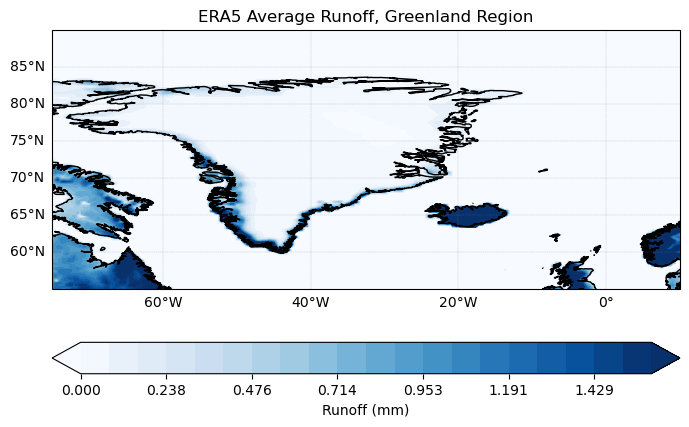

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np

# File path
file_path = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\runoff_full.nc"

# Choosing colourmap
colour_map = "Blues"

# Opening dataset
ds = xr.open_dataset(file_path)

# Variable and coordinate names
time_name = "valid_time" if "valid_time" in ds.coords else "time"
lat_name = "latitude"
lon_name = "longitude"

# Check runoff variable name
print(ds.data_vars)

# ERA5 runoff is ro
runoff_name = "ro"

# Load runoff
runoff = ds[runoff_name]

# Remove 2026
runoff = runoff.sel({
    time_name: slice(None, "2025-12-31")
})

# Convert from metres to mm
runoff_mm = runoff * 1000

# Time average
runoff_avg = runoff_mm.mean(time_name, skipna=True)

# Region
lon_min, lon_max = -75, 10
lat_min, lat_max = 55, 90

# Function to crop fields to region
def crop_to_region(da, lon_min, lon_max, lat_min, lat_max):
    lats = da[lat_name]
    lons = da[lon_name]

    # Convert 0–360 longitude to -180–180 if needed
    if lons.max() > 180:
        da = da.assign_coords({
            lon_name: (((da[lon_name] + 180) % 360) - 180)
        }).sortby(lon_name)

    lats = da[lat_name]
    lons = da[lon_name]

    # Latitude slice
    if lats[0] < lats[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    # Longitude slice
    if lons[0] < lons[-1]:
        lon_slice = slice(lon_min, lon_max)
    else:
        lon_slice = slice(lon_max, lon_min)

    return da.sel({lat_name: lat_slice, lon_name: lon_slice})

# Cropping runoff
runoff_reg = crop_to_region(runoff_avg, lon_min, lon_max, lat_min, lat_max)

# Colour limits
vmin = np.nanpercentile(runoff_reg.values, 2)
vmax = np.nanpercentile(runoff_reg.values, 98)
levels = np.linspace(vmin, vmax, 21)

# Extracting lon/lat for plotting
lon_reg = runoff_reg[lon_name]
lat_reg = runoff_reg[lat_name]

# Choosing map projection
proj = ccrs.PlateCarree()

# Plotting runoff map
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=proj)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax.coastlines(resolution="10m", color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="gray")

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    linestyle="--",
    color="gray",
    alpha=0.5,
    x_inline=False,
    y_inline=False,
)
gl.top_labels = False
gl.right_labels = False

cs = ax.contourf(
    lon_reg,
    lat_reg,
    runoff_reg,
    levels=levels,
    cmap=colour_map,
    transform=proj,
    extend="both"
)

ax.set_title("ERA5 Average Runoff, Greenland Region")

cbar = fig.colorbar(cs, ax=ax, orientation="horizontal", pad=0.08)
cbar.set_label("Runoff (mm)")

plt.tight_layout()
plt.show()

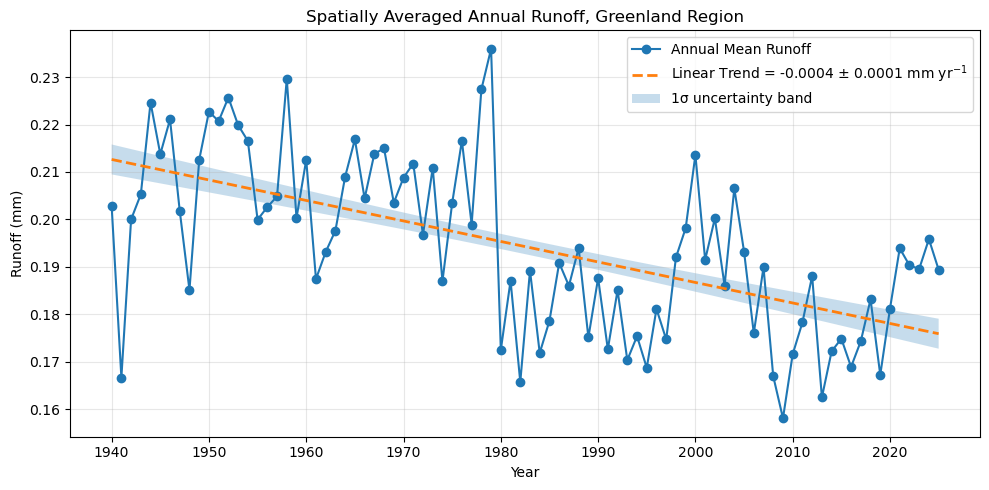

Slope: -0.000432 ± 0.000064 mm/year
Residual σ: 0.014772 mm


In [6]:
import scipy.stats as stats

# Crop to region
runoff_mm_reg = crop_to_region(runoff_mm, lon_min, lon_max, lat_min, lat_max)

# Spatial avg over region
weights = xr.DataArray(
    np.cos(np.deg2rad(runoff_mm_reg[lat_name])),
    coords={lat_name: runoff_mm_reg[lat_name]},
    dims=[lat_name]
)

runoff_spatial = runoff_mm_reg.weighted(weights).mean((lat_name, lon_name))

# Annual means
runoff_annual = runoff_spatial.resample({time_name: "YS"}).mean()

# Drop missing years
runoff_annual = runoff_annual.dropna(time_name)

# Convert to NumPy arrays
time_plot = runoff_annual[time_name].values
x = runoff_annual[time_name].dt.year.values
y = runoff_annual.values

# Linear regression
slope, intercept, r_value, p_value, slope_err = stats.linregress(x, y)

trend_line = intercept + slope * x

# Residuals
residuals = y - trend_line
n = len(y)

# Residual driven 1-sigma
sigma_resid = np.sqrt(np.sum(residuals**2) / (n - 2))

# 1-sigma uncertainty band
x_mean = np.mean(x)
Sxx = np.sum((x - x_mean)**2)

trend_sigma = sigma_resid * np.sqrt(
    (1 / n) + ((x - x_mean)**2 / Sxx)
)

upper_1sigma = trend_line + trend_sigma
lower_1sigma = trend_line - trend_sigma

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    time_plot,
    y,
    marker="o",
    linewidth=1.5,
    label="Annual Mean Runoff"
)

plt.plot(
    time_plot,
    trend_line,
    linestyle="--",
    linewidth=2,
    label=f"Linear Trend = {slope:.4f} ± {slope_err:.4f} mm yr$^{{-1}}$"
)

plt.fill_between(
    time_plot,
    lower_1sigma,
    upper_1sigma,
    alpha=0.25,
    label="1σ uncertainty band"
)

plt.title(f"Spatially Averaged Annual Runoff, Greenland Region")
plt.xlabel("Year")
plt.ylabel("Runoff (mm)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Print stats
print(f"Slope: {slope:.6f} ± {slope_err:.6f} mm/year")
print(f"Residual σ: {sigma_resid:.6f} mm")

Data variables:
    ro       (valid_time, latitude, longitude) float32 600MB ...


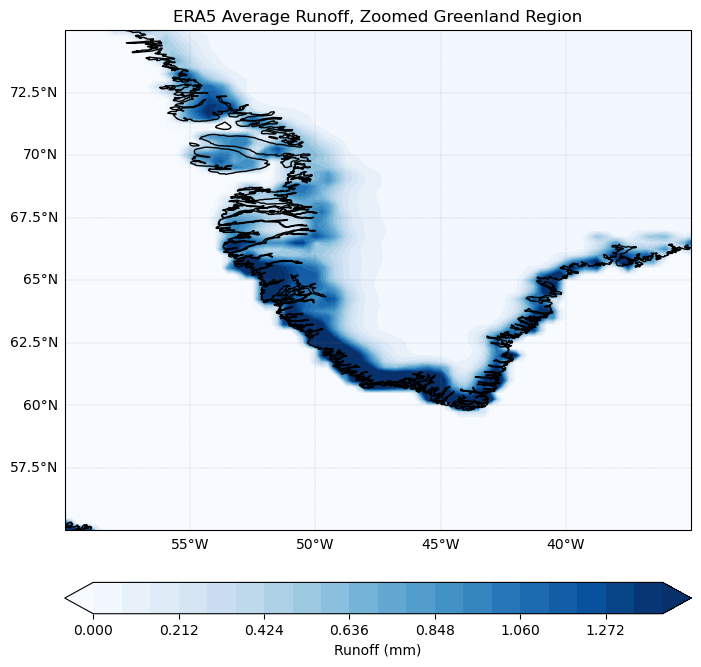

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np

# File path
file_path = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\runoff_full.nc"

# Choosing colourmap
colour_map = "Blues"

# Opening dataset
ds = xr.open_dataset(file_path)

# Variable and coordinate names
time_name = "valid_time" if "valid_time" in ds.coords else "time"
lat_name = "latitude"
lon_name = "longitude"

# Check runoff variable name
print(ds.data_vars)

# ERA5 runoff is ro
runoff_name = "ro"

# Load runoff
runoff = ds[runoff_name]

# Remove 2026
runoff = runoff.sel({
    time_name: slice(None, "2025-12-31")
})

# Convert from metres to mm
runoff_mm = runoff * 1000

# Time average
runoff_avg = runoff_mm.mean(time_name, skipna=True)

# Region
lon_min, lon_max = -60, -35
lat_min, lat_max = 55, 75

# Function to crop fields to region
def crop_to_region(da, lon_min, lon_max, lat_min, lat_max):
    lats = da[lat_name]
    lons = da[lon_name]

    # Convert 0–360 longitude to -180–180 if needed
    if lons.max() > 180:
        da = da.assign_coords({
            lon_name: (((da[lon_name] + 180) % 360) - 180)
        }).sortby(lon_name)

    lats = da[lat_name]
    lons = da[lon_name]

    # Latitude slice
    if lats[0] < lats[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    # Longitude slice
    if lons[0] < lons[-1]:
        lon_slice = slice(lon_min, lon_max)
    else:
        lon_slice = slice(lon_max, lon_min)

    return da.sel({lat_name: lat_slice, lon_name: lon_slice})

# Cropping runoff
runoff_reg = crop_to_region(runoff_avg, lon_min, lon_max, lat_min, lat_max)

# Colour limits
vmin = np.nanpercentile(runoff_reg.values, 2)
vmax = np.nanpercentile(runoff_reg.values, 98)
levels = np.linspace(vmin, vmax, 21)

# Extracting lon/lat for plotting
lon_reg = runoff_reg[lon_name]
lat_reg = runoff_reg[lat_name]

# Choosing map projection
proj = ccrs.PlateCarree()

# Plotting runoff map
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=proj)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax.coastlines(resolution="10m", color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="gray")

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    linestyle="--",
    color="gray",
    alpha=0.5,
    x_inline=False,
    y_inline=False,
)
gl.top_labels = False
gl.right_labels = False

cs = ax.contourf(
    lon_reg,
    lat_reg,
    runoff_reg,
    levels=levels,
    cmap=colour_map,
    transform=proj,
    extend="both"
)

ax.set_title("ERA5 Average Runoff, Zoomed Greenland Region")

cbar = fig.colorbar(cs, ax=ax, orientation="horizontal", pad=0.08)
cbar.set_label("Runoff (mm)")

plt.tight_layout()
plt.show()

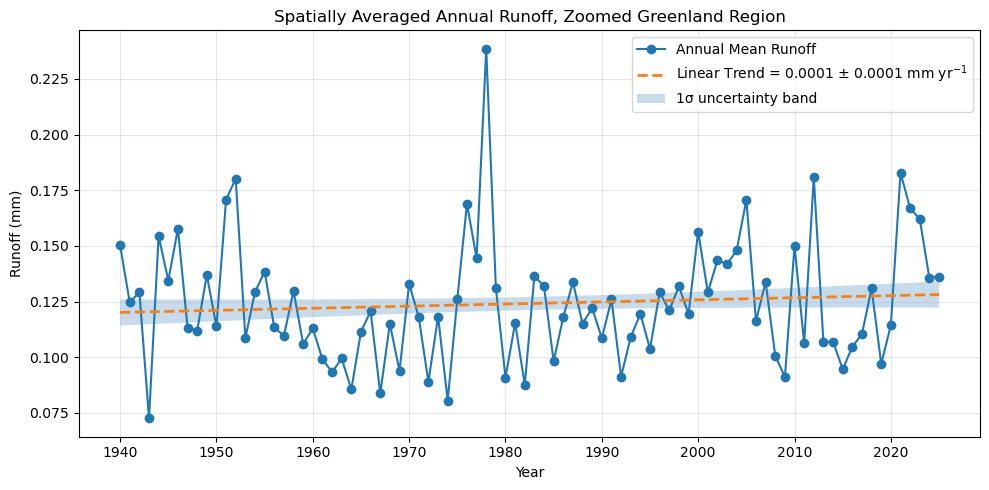

Slope: 0.000094 ± 0.000120 mm/year
Residual σ: 0.027522 mm


In [8]:
import scipy.stats as stats

# Crop to region
runoff_mm_reg = crop_to_region(runoff_mm, lon_min, lon_max, lat_min, lat_max)

# Spatial avg over region
weights = xr.DataArray(
    np.cos(np.deg2rad(runoff_mm_reg[lat_name])),
    coords={lat_name: runoff_mm_reg[lat_name]},
    dims=[lat_name]
)

runoff_spatial = runoff_mm_reg.weighted(weights).mean((lat_name, lon_name))

# Annual means
runoff_annual = runoff_spatial.resample({time_name: "YS"}).mean()

# Drop missing years
runoff_annual = runoff_annual.dropna(time_name)

# Convert to NumPy arrays
time_plot = runoff_annual[time_name].values
x = runoff_annual[time_name].dt.year.values
y = runoff_annual.values

# Linear regression
slope, intercept, r_value, p_value, slope_err = stats.linregress(x, y)

trend_line = intercept + slope * x

# Residuals
residuals = y - trend_line
n = len(y)

# Residual driven 1-sigma
sigma_resid = np.sqrt(np.sum(residuals**2) / (n - 2))

# 1-sigma uncertainty band
x_mean = np.mean(x)
Sxx = np.sum((x - x_mean)**2)

trend_sigma = sigma_resid * np.sqrt(
    (1 / n) + ((x - x_mean)**2 / Sxx)
)

upper_1sigma = trend_line + trend_sigma
lower_1sigma = trend_line - trend_sigma

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    time_plot,
    y,
    marker="o",
    linewidth=1.5,
    label="Annual Mean Runoff"
)

plt.plot(
    time_plot,
    trend_line,
    linestyle="--",
    linewidth=2,
    label=f"Linear Trend = {slope:.4f} ± {slope_err:.4f} mm yr$^{{-1}}$"
)

plt.fill_between(
    time_plot,
    lower_1sigma,
    upper_1sigma,
    alpha=0.25,
    label="1σ uncertainty band"
)

plt.title(f"Spatially Averaged Annual Runoff, Zoomed Greenland Region")
plt.xlabel("Year")
plt.ylabel("Runoff (mm)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Print stats
print(f"Slope: {slope:.6f} ± {slope_err:.6f} mm/year")
print(f"Residual σ: {sigma_resid:.6f} mm")